In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import torch
import os

# Verifica Hardware e Sicurezza (CVE-2025-32434)
print(f"Versione Torch: {torch.__version__}") # Deve essere >= 2.6.0
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Esecuzione su: {device} (RTX 4070)")

# Caricamento del modello Multilingua BGE-M3
model = SentenceTransformer("BAAI/bge-m3", device=device)

c:\Users\cappe\Downloads\Progetti\AI-Engineer-Roadmap\Sentinel-RAG\rag_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Versione Torch: 2.6.0+cu124
Esecuzione su: cuda (RTX 4070)


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 94078.30it/s]


In [2]:
# Definiamo le query di test basate sul paper "Attention Is All You Need"
test_queries = [
    {"query": "Qual è il vantaggio principale dell'Attention rispetto alle RNN?", "correct_id": 0},
    {"query": "Spiegazione del meccanismo di Multi-Head Attention", "correct_id": 1},
    {"query": "Come viene gestito il Positional Encoding?", "correct_id": 2},
    {"query": "Risultati del modello sul task English-to-German", "correct_id": 3}
]

# Per simulare il comportamento del tuo database reale, 
# generiamo gli embedding delle risposte corrette (chunk)
# In produzione, questi verrebbero letti da ChromaDB
chunk_texts = [
    "L'attenzione permette la parallelizzazione totale a differenza delle RNN seriali.",
    "Il Multi-Head Attention proietta query, chiavi e valori in diversi spazi di rappresentazione.",
    "Il Positional Encoding usa funzioni sinusoidali per iniettare l'ordine delle parole.",
    "Il modello ha ottenuto 28.4 BLEU nel task WMT 2014 English-to-German."
]

# Generazione embedding per i chunk (i nostri "documenti" nel Vector DB)
document_embeddings = model.encode(chunk_texts, normalize_embeddings=True)

In [3]:
from sklearn.metrics.pairwise import cosine_similarity

def run_evaluation(model, queries, doc_embeddings, k_values=[1, 3, 5]):
    eval_data = {"k": [], "hit_rate": [], "mrr": []}
    
    for k in k_values:
        hits = 0
        sum_rr = 0 # Reciprocal Rank
        
        for q in queries:
            # Embedding della domanda
            query_emb = model.encode(q["query"], normalize_embeddings=True).reshape(1, -1)
            
            # Calcolo similarità con tutti i documenti
            scores = cosine_similarity(query_emb, doc_embeddings)[0]
            
            # Prendiamo i top K indici
            top_k = np.argsort(scores)[::-1][:k]
            all_ranks = np.argsort(scores)[::-1]
            
            # --- HIT RATE ---
            if q["correct_id"] in top_k:
                hits += 1
            
            # --- MRR ---
            rank = np.where(all_ranks == q["correct_id"])[0][0] + 1
            if rank <= k:
                sum_rr += (1 / rank)
        
        eval_data["k"].append(k)
        eval_data["hit_rate"].append(hits / len(queries))
        eval_data["mrr"].append(sum_rr / len(queries))
        
    return pd.DataFrame(eval_data)

# Eseguiamo i test su diversi valori di K
df_results = run_evaluation(model, test_queries, document_embeddings, k_values=[1, 2, 3, 5])
print("Risultati Valutazione:\n", df_results)

Risultati Valutazione:
    k  hit_rate  mrr
0  1       1.0  1.0
1  2       1.0  1.0
2  3       1.0  1.0
3  5       1.0  1.0


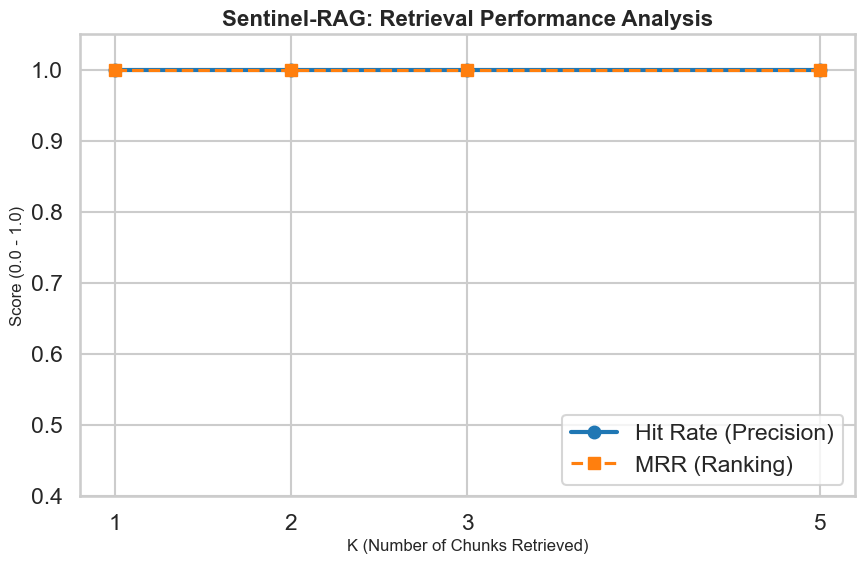


✅ Analisi completata! Grafico salvato in 'assets/retrieval_metrics.png'


In [ ]:
import seaborn as sns
import os

plt.figure(figsize=(10, 6))
sns.set_context("talk")
sns.set_style("whitegrid")

# Plot Hit Rate e MRR
plt.plot(df_results['k'], df_results['hit_rate'], marker='o', label='Hit Rate (Precision)', color='#1f77b4', linewidth=3)
plt.plot(df_results['k'], df_results['mrr'], marker='s', label='MRR (Ranking)', color='#ff7f0e', linestyle='--')


plt.title("Sentinel-RAG: Retrieval Performance Analysis", fontsize=16, fontweight='bold')
plt.xlabel("K (Number of Chunks Retrieved)", fontsize=12)
plt.ylabel("Score (0.0 - 1.0)", fontsize=12)
plt.xticks([1, 2, 3, 5])
plt.ylim(0.4, 1.05)
plt.legend(loc='lower right')

# Salvataggio immagine per il README
os.makedirs('../assets', exist_ok=True)
plt.savefig('../assets/retrieval_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ Analisi completata! Grafico salvato in 'assets/retrieval_metrics.png'")